# Brownian Bridge Path Construction


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/brownian_bridge.ipynb)

`BrownianMotion` supports multiple path construction methods via the `decomp_type` parameter, including `'PCA'` and `'Cholesky'`. This notebook introduces `'BrownianBridge'`, which samples the terminal value first using the first QMC dimension, then fills in midpoints recursively. This ensures that each QMC dimension is used in decreasing order of influence on the path. 

In [24]:
from qmcpy import *
import numpy as np
from matplotlib import pyplot
%matplotlib inline
pyplot.rc('font', size=14)
pyplot.rc('axes', titlesize=14)
pyplot.rc('axes', labelsize=14)
pyplot.rc('xtick', labelsize=14)
pyplot.rc('ytick', labelsize=14)
pyplot.rc('legend', fontsize=14)
pyplot.rc('figure', titlesize=14)

## Basic Usage


The `decomp_type` parameter is documented in the `BrownianMotion` constructor:

In [25]:
help(BrownianMotion.__init__)

Help on function __init__ in module qmcpy.true_measure.brownian_motion:

__init__(
    self,
    sampler,
    t_final=1,
    initial_value=0,
    drift=0,
    diffusion=1,
    decomp_type='PCA',
    lazy_decomp=True
)
    Args:
        sampler (Union[AbstractDiscreteDistribution, AbstractTrueMeasure]): Either

            - a discrete distribution from which to transform samples, or
            - a true measure by which to compose a transform.
        t_final (float): End time.
        initial_value (float): Initial value $B_0$.
        drift (int): Drift $\gamma$.
        diffusion (int): Diffusion $\sigma^2$.
        decomp_type (str): Method for decomposition for covariance matrix. Options include

            - `'PCA'` for principal component analysis,
            - `'Cholesky'` for cholesky decomposition, or
            - `'BrownianBridge'` for brownian bridge construction.
        lazy_decomp (bool): If True, defer expensive matrix decomposition until needed.



In [26]:
l4 = Lattice(4, seed=7)
bm = BrownianMotion(l4, decomp_type='BrownianBridge')
bm, l4(1)

(BrownianMotion (AbstractTrueMeasure)
     time_vec        [0.25 0.5  0.75 1.  ]
     drift           0
     mean            [0. 0. 0. 0.]
     covariance      [[0.25 0.25 0.25 0.25]
                      [0.25 0.5  0.5  0.5 ]
                      [0.25 0.5  0.75 0.75]
                      [0.25 0.5  0.75 1.  ]]
     decomp_type     BROWNIANBRIDGE,
 array([[0.04386058, 0.58727432, 0.3691824 , 0.65212985]]))

In [27]:
x4 = bm.gen_samples(4)
x4

array([[-0.48984474, -0.74350199, -1.08725591, -1.70754305],
       [ 0.084984  , -0.62378384, -0.62002968,  0.1101646 ],
       [-0.65738278, -0.4810274 , -0.59920835, -0.54214131],
       [ 0.55804662,  0.90160358,  1.31816823,  0.81988997]])

In [28]:
l2 = Lattice(2, seed=7)
bm2 = BrownianMotion(l2, decomp_type='BrownianBridge')
bm2, l2(1)

(BrownianMotion (AbstractTrueMeasure)
     time_vec        [0.5 1. ]
     drift           0
     mean            [0. 0.]
     covariance      [[0.5 0.5]
                      [0.5 1. ]]
     decomp_type     BROWNIANBRIDGE,
 array([[0.04386058, 0.58727432]]))

In [29]:
x2 = bm2.gen_samples(4) 
x2

array([[-0.74350199, -1.70754305],
       [-0.62378384,  0.1101646 ],
       [-0.4810274 , -0.54214131],
       [ 0.90160358,  0.81988997]])

In [30]:
assert (x4[...,[1,3]]==x2).all(), "requires the observations with d=4 at times 0.5 and 1 to match those at d=2"

## Brownian Bridge Construction

Given a Brownian motion $W$ with $W(0) = 0$, the conditional distribution of an interior value given its two surrounding anchor points is

$$W(t_\text{mid}) \;\Big|\; W(t_\text{left}) = a,\; W(t_\text{right}) = b \;\sim\; \mathcal{N}(\mu,\, \sigma^2)$$

where

$$\mu = a + \frac{t_\text{mid} - t_\text{left}}{t_\text{right} - t_\text{left}}(b - a), \qquad \sigma^2 = \frac{(t_\text{mid} - t_\text{left})(t_\text{right} - t_\text{mid})}{t_\text{right} - t_\text{left}}.$$

The construction:

1. Sample $W(T)$ using QMC dimension 1. The standard deviation
   $\sqrt{T}$ of this point is the largest of any point on the path.
2. Given $W(0) = 0$ and $W(T)$, sample the midpoint $W(T/2)$ using 
   dimension 2, with standard deviation $\sqrt{T}/2$.
3. Sample $W(T/4)$ and $W(3T/4)$ using dimensions 3 and 4.
4. Continue bisecting each interval, and at each level the conditional 
   standard deviation decreases.

This ordering places the nodes with the highest variance in the leading QMC dimensions, which are the most uniform, decreasing the effective dimension [[1](#ref1), [2](#ref2), [3](#ref3)].

### Non-Power-of-2 Dimensions

When $d$ is a power of 2, bisection produces a balanced tree and conditional standard deviations decrease cleanly at each iteration. When $d$ is not a power of 2, the bisection uses $\lfloor(\text{left} + \text{right}) / 2\rfloor$ as the midpoint index, leading to unequal subintervals. In a lopsided tree, nodes at the same level can have different standard deviations, which no longer guarantees that the nodes with higher variance are assigned to the higher quality dimensions.

To ensure that the highest variance nodes are assigned to the highest quality dimension for any $d$, all nodes are collected first, then sorted by decreasing $\sigma$ before QMC dimensions are assigned. This ensures that the midpoints with the highest variance always receive the leading dimensions regardless of $d$. A `ParameterWarning` is issued when $d$ is not a power of 2, since the bisection tree is no longer balanced.

## Path Construction for Increasing $d$

BrownianBridge paths for $d \in \{1, 2, 3, 4, 5, 6, 7, 8, 128\}$. For powers of 2 ($d = 4$ and $d = 8$), paths at shared time points are identical, meaning that the $d = 8$ paths are essentially a refinement of the $d = 4$ paths. Going from $d = 4$ to $d = 8$ simply inserts new points in between existing points. For non-powers of 2 ($d = 5, 6, 7$), the bisection adds time points at non-midpoint locations.

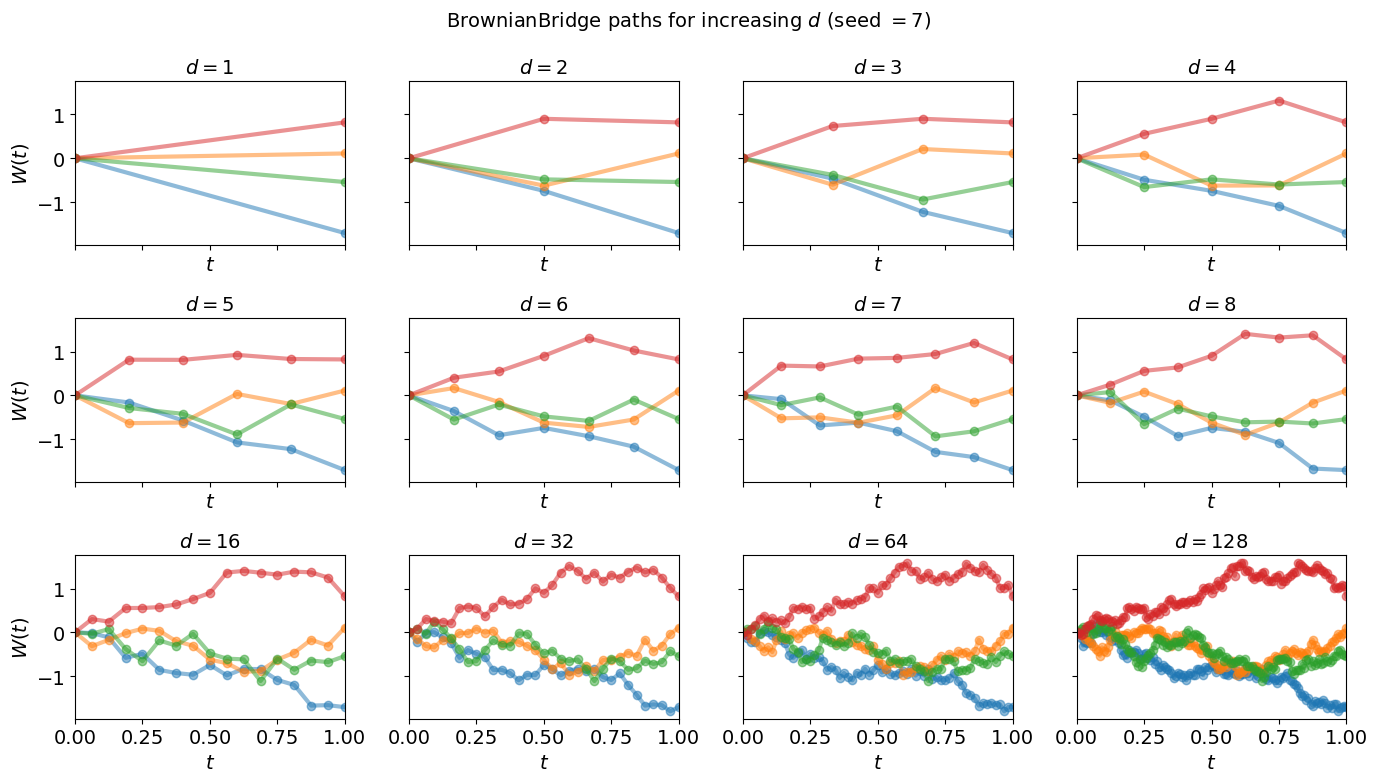

In [31]:
import warnings

dims = [1,2,3,4,5,6,7,8,16,32,64,128]
n = 4
t_final = 1.0
seed = 7

fig, axes = pyplot.subplots(3, 4, figsize=(14, 8), sharey=True, sharex=True)
axes_flat = axes.flatten()

for ax, d in zip(axes_flat, dims):
    # Pick the first d time points by index
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bm_full = BrownianMotion(Lattice(d, seed=seed), t_final=t_final, decomp_type='BrownianBridge')
    paths = bm_full.gen_samples(n)
    paths_full = np.concat([np.zeros((n,1)),paths],axis=-1)
    times = np.concat([[0],bm_full.time_vec])
    ax.plot(times, paths_full.T, "-o",alpha=0.5, linewidth=3)
    ax.set_title(f'$d = {d}$')
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)

for ax in axes[:, 0]:
    ax.set_ylabel('$W(t)$')
pyplot.suptitle('BrownianBridge paths for increasing $d$ (seed $= 7$)')
pyplot.tight_layout()
pyplot.show()

## Comparing Decomposition Types

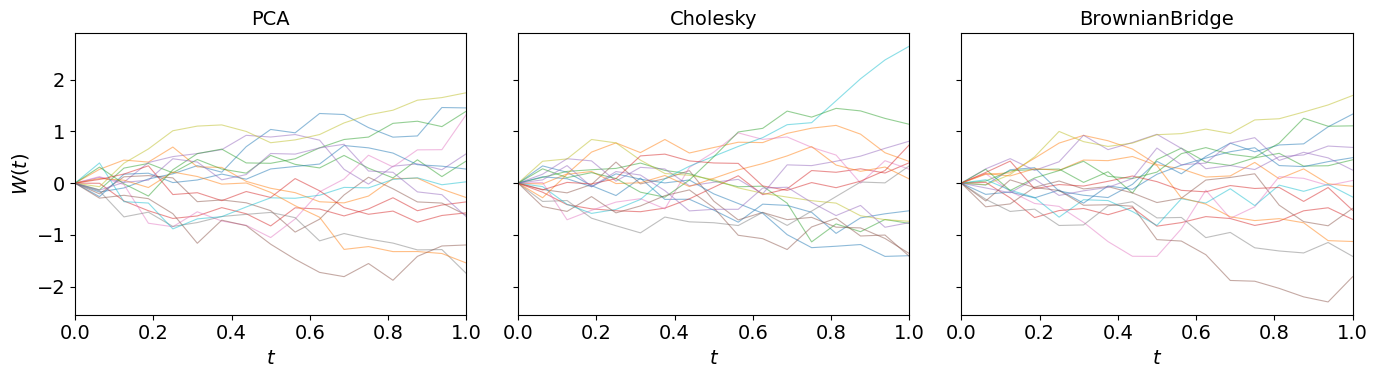

In [32]:
d = 16
n = 16
t_final = 1.0

fig, axes = pyplot.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, decomp in zip(axes, ['PCA', 'Cholesky', 'BrownianBridge']):
    bm = BrownianMotion(DigitalNetB2(d, seed=7), t_final=t_final, decomp_type=decomp)
    paths = bm.gen_samples(n)
    time_vec = np.concatenate([[0], bm.time_vec])
    paths_with_origin = np.hstack([np.zeros((n, 1)), paths])
    for path in paths_with_origin:
        ax.plot(time_vec, path, alpha=0.5, linewidth=0.8)
    ax.set_title(decomp)
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)
axes[0].set_ylabel('$W(t)$')
pyplot.tight_layout()
pyplot.show()

## Option Pricing

An Asian call option priced under each `decomp_type`:

In [33]:
d = 16        # monitoring dates
n = 2**10     # QMC samples
vol = 0.2     # volatility
S0 = 100.0    # initial stock price
K = 100.0     # strike price
r = 0.05      # risk-free rate
t_final = 1.0 # time horizon (years)

In [34]:
print(f"{'decomp_type':<16}  {'price':>8}")
print('-' * 28)
for decomp in ['PCA', 'Cholesky', 'BrownianBridge']:
    option = FinancialOption(
        DigitalNetB2(d, seed=7),
        option='ASIAN',
        volatility=vol,
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        t_final=t_final,
        call_put='call',
        asian_mean='arithmetic',
        decomp_type=decomp,
    )
    print(f"{decomp:<16}  {option(n).mean():>8.4f}")

decomp_type          price
----------------------------
PCA                 5.7618
Cholesky            5.7432
BrownianBridge      5.7505


## References

<a id="ref1"></a>
[1] Caflisch, R.E., Morokoff, W., and Owen, A.B. (1997). "Valuation of mortgage-backed securities using Brownian bridges to reduce effective dimension." Journal of Computational Finance, 1(1), 27–46.

<a id="ref2"></a>
[2] Glasserman, P. (2004). Monte Carlo Methods in Financial Engineering. Springer, New York. pp. 82–92.

<a id="ref3"></a>
[3] Lin, J. and Wang, X. (2008). "New Brownian bridge construction in quasi-Monte Carlo methods for computational finance." Journal of Complexity, 24(2), 109–133.